In [14]:
import re
import numpy as np
import pandas as pd
import os as os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math
from sklearn.linear_model import LinearRegression
from scipy.ndimage import gaussian_filter
tableau_colors = list(mcolors.TABLEAU_COLORS.values())
from datetime import datetime

plt.rcParams.update({
    'axes.labelsize': 12,   # 坐标轴标签大小
})

In [10]:
# Function to find y value (I) corresponding to given x value (potential)
# It finds the index of the element in the array x that is closest to the target_x value using 
def find_y(x, y, target_x):
    index = np.argmin(np.abs(x - target_x))
    return y[index]

def find_y_exact(x,y,target_x):
    index = np.where(x == target_x)[0]
    return y[index]

def rpm_to_rads(rpm):
    rps = rpm / 60  # Convert RPM to RPS (revolutions per second)
    rad_per_sec = 2 * math.pi * rps  # Convert RPS to rad/s
    return rad_per_sec

# def example_plot(df,Ei):
#     df_all = {}
#     for i in range(200,1500,200):
#         file = filepath + "\\G_P_KOH40gLDMAB0.05gL_%drpm_1mVs_HDV.xlsx" % i 
#         if os.path.exists(file) and file.endswith("HDV.xlsx"):
#             print(i)
#             num = str(i)  + "rpm"
#             data0 = pd.ExcelFile(file)
#             df = data0.parse('Sheet1')
#             df['rpm'] = i
#             df['rad'] = df['rpm'] * 2 * math.pi / 60
#             df['rad_m0.5'] = 1./ df['rad'] ** 0.5
#             df['i_inverse'] = 1./ df['WE(1).Current (A)']
#             E = df['Potential applied (V)']
#             af_all.append(df)
    
#     for j in range(len(E))
#     for i in range(len(E)):
#         E = df['Potential applied (V)']
#         df['rpm'] = i
#         df['rad'] = df['rpm'] * 2 * math.pi / 60
#         df['rad_m0.5'] = 1./ df['rad'] ** 0.5
#         df['i_inverse'] = 1./ df['WE(1).Current (A)']
#         i_inverse = df['i_inverse']
#         w05 = df['rad_m0.5']
#         if E[i] == Ei:
#             return w05, i_inverse

def reorder(filename):
    match = re.search(r'(\d+)rpm', filename)
    if match:
        return int(match.group(1))
    else:
        # Handle files without RPM values
        return -1  # You can use any default value or treatment
    
def create_file_template(file_name):
    # Use a regular expression to find the rpm part
    pattern = r'(\d+)rpm'
    
    # Replace the numeric rpm part with a placeholder for formatting later
    template = re.sub(pattern, '%drpm', file_name)
    
    return template

def get_d_range():
    try:
        d_min = float(input("Enter the minimum value for D: "))
        d_max = float(input("Enter the maximum value for D: "))
        if d_min >= d_max:
            print("Minimum value should be less than maximum value.")
            return get_d_range()
        return d_min, d_max
    except ValueError:
        print("Please enter valid numbers.")
        return get_d_range()

In [11]:
folder_name = "05202024_HDV_D40_A1"
filepath="C:\\Users\\Grant Xue\\OneDrive\\Desktop\\" + folder_name
files = os.listdir(filepath)

file_name = "\\HDV_G_DMAB0.05gL_10mVs_200rpm.xlsx"
file_names = create_file_template(file_name)
result_path = 'C:\\Users\\Grant Xue\\OneDrive\\Desktop\\J. Electroanalytical Chemistry 2023\\images_300DPI'
print("file_names:", file_names)
data_range = range(200, 2200, 200)
files = sorted(files, key=reorder)

for file in files:
    print(file)


file_names: \HDV_G_DMAB0.05gL_10mVs_%drpm.xlsx
DMAB_RDE(3).nox
HDV_combined_data.xlsx
HDV_G_DMAB0.05gL_10mVs_200rpm.xlsx
HDV_G_DMAB0.05gL_10mVs_400rpm.xlsx
HDV_G_DMAB0.05gL_10mVs_600rpm.xlsx
HDV_G_DMAB0.05gL_10mVs_800rpm.xlsx
HDV_G_DMAB0.05gL_10mVs_1000rpm.xlsx
HDV_G_DMAB0.05gL_10mVs_1200rpm.xlsx
HDV_G_DMAB0.05gL_10mVs_1400rpm.xlsx
HDV_G_DMAB0.05gL_10mVs_1600rpm.xlsx
HDV_G_DMAB0.05gL_10mVs_1800rpm.xlsx
HDV_G_DMAB0.05gL_10mVs_2000rpm.xlsx


In [12]:
# # Specify the path to your text file (skip if your are the xlsx files)
# file_name_txt = "\\HDV_G_KNO3_K3FeCN6_0.5to-0.1_4mM_1mVs_200rpm.xlsx"
# file_names_txt = "\\HDV_G_DMAB_5mVs_%drpm.txt"

# for i in data_range:
#     file = filepath + file_names_txt % i
#     if os.path.exists(file) and file.endswith(".txt"):
#         print(file)
#         rpm = str(i)  + "rpm"
#         # Open the file in read mode ('r')
#         with open(file, 'r') as file:
#             # Read the entire content of the file into a string
#             # Read the text file into a DataFrame
#             df = pd.read_csv(file, delimiter=';')

#             # Extract the desired columns
#             I = df['WE(1).Current (A)']
#             E = df['WE(1).Potential (V)']

#             # Print or process the content as needed
#             plt.scatter(E, I, label=rpm, s=1)
            
# plt.xlabel('Applied potential/V')
# plt.ylabel('Current/A')
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# #plt.xlim()
# # plt.ylim(-0.0002,0.0003)
# plt.legend()
# plt.grid()
# plt.show()

C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_200rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_400rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_600rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_800rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_1000rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_1200rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_1400rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_1600rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_1800rpm.xlsx
length of E: 3714
C:\Users\Grant

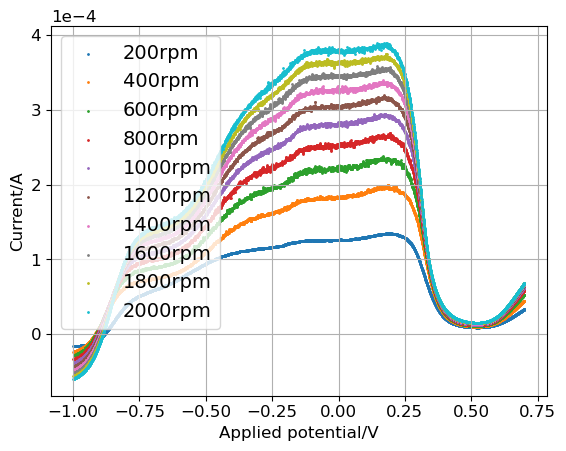

In [15]:
# plot figure modlue

# Create an empty DataFrame to store the data
# combined_data = pd.DataFrame()
# input your rpm ramge here
for i in data_range:
    #input your file name here and switch rpm in to %d
    file = filepath + file_names % i 
#     print(file)
    if os.path.exists(file) and file.endswith(".xlsx"):
        print(file)
        rpm = str(i)  + "rpm"
        data0 = pd.ExcelFile(file)
        df = data0.parse('Sheet1')
        E = df['WE(1).Potential (V)']
        I = df['WE(1).Current (A)']
        print("length of E:",len(E))
        plt.scatter(E, I, label=rpm, s=1)
        
#         # Create a new DataFrame for the current RPM
#         rpm_data = pd.DataFrame({'Potential (V)' + rpm: E, 'Current (A)' + rpm: I})
        
#         # Concatenate the data for this RPM to the right of the combined_data DataFrame
#         combined_data = pd.concat([combined_data, rpm_data], axis=1)


                        
plt.xlabel('Applied potential/V')
plt.ylabel('Current/A')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.xlim()
# plt.ylim(-0.0002,0.0003)
plt.legend()
plt.grid()
plt.show()


Electrode area = 0.0707 cm^2
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_200rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_400rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_600rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_800rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_1000rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_1200rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_1400rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_1600rpm.xlsx
length of E: 3714
C:\Users\Grant Xue\OneDrive\Desktop\05202024_HDV_D40_A1\HDV_G_DMAB0.05gL_10mVs_1800rpm.xlsx
len

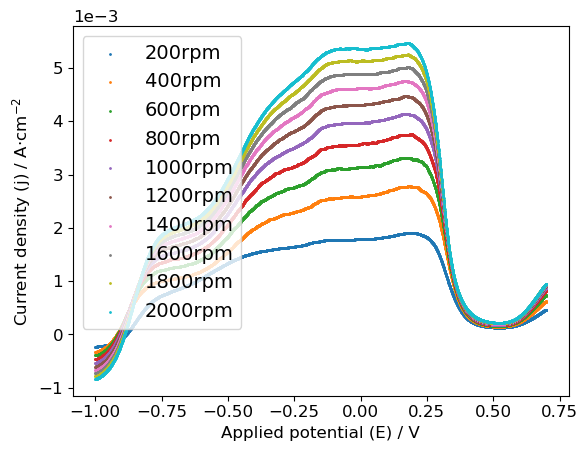

HDV_DMAB_jV saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI


In [16]:
# plot figure modlue with Gaussian filter

# Create an empty DataFrame to store the data
combined_data = pd.DataFrame()

electrode_diameter = 3  # mm
r_cm = (electrode_diameter / 10) / 2  
A = np.pi * (r_cm**2)

print(f"Electrode area = {A:.4f} cm^2")

# input your rpm ramge here
for i in data_range:
    #input your file name here and switch rpm in to %d
    file = filepath + file_names % i 
    if os.path.exists(file) and file.endswith(".xlsx"):
        print(file)
        rpm = str(i)  + "rpm"
        data0 = pd.ExcelFile(file)
        df = data0.parse('Sheet1')
        E = df['Potential applied (V)']
        I = df['WE(1).Current (A)']
        den_j = I/A
        # Define the standard deviation (sigma) for the Gaussian filter
        sigma = 10.0  # You can adjust this as needed
        # Apply the Gaussian filter to the 'Current (A)'
        smoothed_I = gaussian_filter(I, sigma=sigma)
        smoothed_j = gaussian_filter(den_j, sigma=sigma)        
        print("length of E:",len(E))
        plt.scatter(E, smoothed_j, label=rpm, s=1)
        
#         # Create a new DataFrame for the current RPM
#         rpm_data = pd.DataFrame({'Potential (V)' + rpm: E, 'Current (A)' + rpm: I})
#         # Concatenate the data for this RPM to the right of the combined_data DataFrame
#         combined_data = pd.concat([combined_data, rpm_data], axis=1)


                        
# plt.xlabel('Applied\ potential\ /\ mathrm{V}')
# plt.ylabel('Current\ /\ mathrm{A}')
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# # plt.xlim(-0.4,1.0)
# # plt.ylim(-0.1e-4,0.3e-4)
# plt.legend()
# # plt.grid()

# # Save as high-resolution PNG and Vector PDF
# output_name = 'HDV_DMAB_IV'
# output_path = result_path
# os.makedirs(output_path, exist_ok=True)
# output_file = os.path.join(output_path, output_name + '.png')  # For raster format
# plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
# # plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
# plt.show()
# print(f"{output_name} saved in {result_path}")

plt.xlabel(r'Applied potential (E) / V')
plt.ylabel(r'Current density (j) / A$\cdot$cm$^{-2}$')

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# plt.xlim(-0.4,1.0)
# plt.ylim(-0.1e-4,0.3e-4)
plt.legend()
# plt.grid()

# Save as high-resolution PNG and Vector PDF
output_name = 'HDV_DMAB_jV'
output_path = result_path
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, output_name + '.png')  # For raster format
plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
# plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
plt.show()
print(f"{output_name} saved in {result_path}")

# # Save the combined data to a new Excel file
# combined_data.to_excel(filepath + '\\HDV_combined_data.xlsx', index=False)

Processing


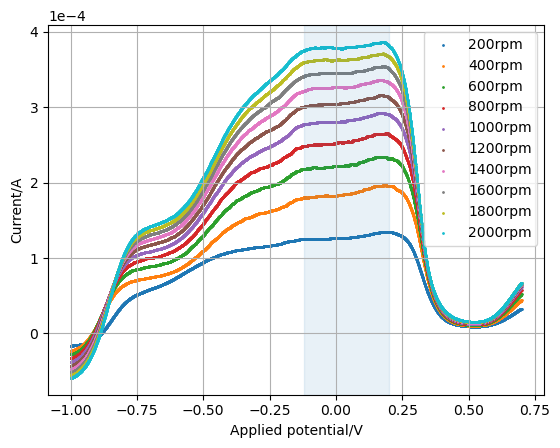

[(-0.12, 0.2)]
Done 2025-08-18 16:35:47


In [15]:
## input D_ranges

# D_ranges = [(-0.80,-0.60),(-0.15,0.10),(0.10,0.25)]
# D_ranges = [(-0.30, -0.175), (0.45, 0.55)]
D_ranges = [(-0.12, 0.2)]

print("Processing")
# Create an empty DataFrame to store the data
combined_data = pd.DataFrame()
# input your rpm ramge here
for i in data_range:
    #input your file name here and switch rpm in to %d
    file = filepath + file_names % i 
    if os.path.exists(file) and file.endswith(".xlsx"):
#         print(file)
        rpm = str(i)  + "rpm"
        data0 = pd.ExcelFile(file)
        df = data0.parse('Sheet1')
        E = df['Potential applied (V)']
        I = df['WE(1).Current (A)']
        # Define the standard deviation (sigma) for the Gaussian filter
        sigma = 10.0  # You can adjust this as needed
        # Apply the Gaussian filter to the 'Current (A)'
        smoothed_I = gaussian_filter(I, sigma=sigma)
#         print("length of E:",len(E))
        plt.scatter(E, smoothed_I, label=rpm, s=1)
        
        # Create a new DataFrame for the current RPM
        rpm_data = pd.DataFrame({'Potential (V)' + rpm: E, 'Current (A)' + rpm: I})
        # Concatenate the data for this RPM to the right of the combined_data DataFrame
        combined_data = pd.concat([combined_data, rpm_data], axis=1)


for i, d_range in enumerate(D_ranges):
    color_value = tableau_colors[i % len(tableau_colors)]  # Cycle through Tableau colors
    plt.axvspan(d_range[0], d_range[1], ymin=0, ymax=1, alpha=0.1, color=color_value)
    
plt.xlabel('Applied potential/V')
plt.ylabel('Current/A')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# plt.xlim(-0.4,1.0)
# plt.ylim(-0.1e-4,0.3e-4)
plt.legend()
plt.grid()
plt.show()
print(D_ranges)

#==============================
# Get the current date and time
current_time = datetime.now()
# Format the date and time
formatted_time = current_time.strftime("%Y-%m-%d %H:%M:%S")
# Print the formatted date and time
print("Done",formatted_time)

In [16]:
D_ranges = [(-0.80,-0.60),(-0.15,0.10),(0.10,0.25)]

In [17]:
# Checking combined data
combined_data

,Potential (V)200rpm,Current (A)200rpm,Potential (V)400rpm,Current (A)400rpm,Potential (V)600rpm,Current (A)600rpm,Potential (V)800rpm,Current (A)800rpm,Potential (V)1000rpm,Current (A)1000rpm,Potential (V)1200rpm,Current (A)1200rpm,Potential (V)1400rpm,Current (A)1400rpm,Potential (V)1600rpm,Current (A)1600rpm,Potential (V)1800rpm,Current (A)1800rpm,Potential (V)2000rpm,Current (A)2000rpm
0,-0.999603,-0.000016,-0.999603,-0.000023,-0.999603,-0.000028,-0.999603,-0.000033,-0.999603,-0.000038,-0.999603,-0.000043,-0.999603,-0.000048,-0.999603,-0.000052,-0.999603,-0.000056,-0.999603,-0.000060
1,-0.999146,-0.000016,-0.999146,-0.000023,-0.999146,-0.000028,-0.999146,-0.000033,-0.999146,-0.000037,-0.999146,-0.000043,-0.999146,-0.000048,-0.999146,-0.000052,-0.999146,-0.000056,-0.999146,-0.000059
2,-0.998688,-0.000016,-0.998688,-0.000023,-0.998688,-0.000028,-0.998688,-0.000033,-0.998688,-0.000038,-0.998688,-0.000043,-0.998688,-0.000048,-0.998688,-0.000052,-0.998688,-0.000056,-0.998688,-0.000059
3,-0.998230,-0.000016,-0.998230,-0.000023,-0.998230,-0.000028,-0.998230,-0.000033,-0.998230,-0.000038,-0.998230,-0.000043,-0.998230,-0.000047,-0.998230,-0.000052,-0.998230,-0.000056,-0.998230,-0.000059
4,-0.997772,-0.000016,-0.997772,-0.000023,-0.997772,-0.000028,-0.997772,-0.000033,-0.997772,-0.000037,-0.997772,-0.000043,-0.997772,-0.000048,-0.997772,-0.000052,-0.997772,-0.000056,-0.997772,-0.000059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3709,0.698242,0.000033,0.698242,0.000044,0.698242,0.000052,0.698242,0.000058,0.698242,0.000062,0.698242,0.000065,0.698242,0.000066,0.698242,0.000067,0.698242,0.000068,0.698242,0.000067
3710,0.698700,0.000033,0.698700,0.000044,0.698700,0.000053,0.698700,0.000058,0.698700,0.000062,0.698700,0.000065,0.698700,0.000067,0.698700,0.000067,0.698700,0.000068,0.698700,0.000068
3711,0.699158,0.000033,0.699158,0.000045,0.699158,0.000053,0.699158,0.000059,0.699158,0.000063,0.699158,0.000065,0.699158,0.000067,0.699158,0.000068,0.699158,0.000068,0.699158,0.000068
3712,0.699615,0.000034,0.699615,0.000045,0.699615,0.000053,0.699615,0.000059,0.699615,0.000063,0.699615,0.000065,0.699615,0.000067,0.699615,0.000068,0.699615,0.000068,0.699615,0.000068


electrode Radius is : 0.15 cm
surface area is : 0.07068583470577035 cm²
E in Ascending order
start_index: 1922 end_index: 2620
potential 1 : -0.1198 V
potential 2 : -0.0562 V
potential 3 : 0.0079 V
potential 4 : 0.0716 V
potential 5 : 0.1357 V
potential 6 : 0.1997 V


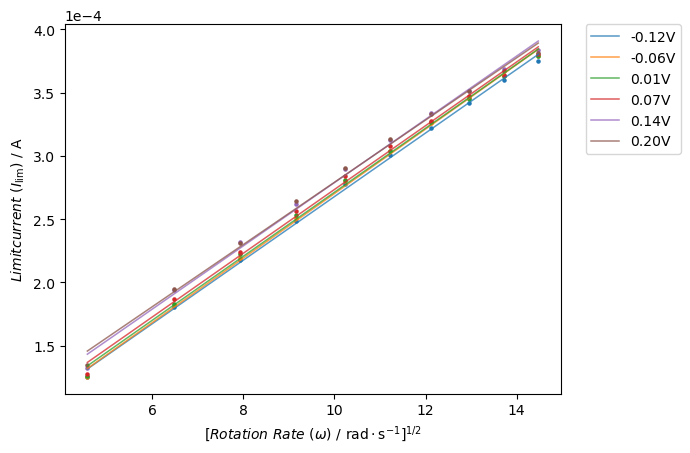

L_DMAB saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
Summary Table of Calculated Parameters:
      Potential  Levich slope  Diffusion Coefficient
1922  -0.119781      0.000025               0.000018
2061  -0.056152      0.000025               0.000018
2201   0.007935      0.000025               0.000018
2340   0.071564      0.000025               0.000018
2480   0.135651      0.000025               0.000018
2620   0.199738      0.000025               0.000018


In [8]:
# show example Levich plot module V2: updated in May 24th 2024

# Define constants and parameters_These are setting parameter
start_value = -0.12  # Starting value of the range for potential
end_value = 0.2  # Ending value of the range for potential
n_points = 6  # Number of points to select
rpm_range = range(200, 2200, 100)  # RPM range for the files
# These are calculation parameter
n = 1
relectrode = 0.15 # Radius of the rotate electrode in cm
print('electrode Radius is :',relectrode,'cm')
A = np.pi*(relectrode**2)
print('surface area is :',A,'cm\u00b2')
v = 0.01 # kinematic viscosity of the solution (ν - cm2/s), 
C = 0.004e-3 #in mol/cm3

# Load data
Levich_plotshow_data = pd.DataFrame()
file = filepath + file_name
data0 = pd.ExcelFile(file)
df = data0.parse('Sheet1')
E = df['Potential applied (V)']

# Calculate the corresponding indices within the range
if E.iloc[0] < E.iloc[-1]:  # Ascending order
    start_index = E[E >= start_value].idxmin()
    end_index = E[E <= end_value].idxmax()
    print("E in Ascending order")
else:  # Descending order
    start_index = E[E <= end_value].idxmax()
    end_index = E[E >= start_value].idxmin()
    print("E in Descending order")

print("start_index:", start_index, "end_index:", end_index)

points_number = np.linspace(start_index, end_index, n_points, dtype=int)
E_selected = E.iloc[points_number]
Levich_slope = []
Levich_intercept = []
D = []

for j, potential in enumerate(E_selected):
    print(f"potential {j+1} : {potential:.4f} V")
    I_elected = []
    w_05 = []
 
    for i in rpm_range:
        #input your file name here and switch rpm in to %d
        file = filepath + file_names % i 
        if os.path.exists(file) and file.endswith(".xlsx"):
            data0 = pd.ExcelFile(file)
            df = data0.parse('Sheet1')
            # x axis（w）
            rpm = i
            w_i = rpm_to_rads(rpm)
            w05_i = w_i ** 0.5
            w_05.append(w05_i)

            # y axis (Ii)
            E = df['Potential applied (V)']
            I = df['WE(1).Current (A)']
            # Apply the Gaussian filter to the 'Current (A)'
            smoothed_I = gaussian_filter(I, sigma=sigma)
            
            I_potential_i = find_y(E,smoothed_I,potential)
            #print(I_potential_i)
            I_elected.append(I_potential_i)
        
    plt.scatter(w_05, I_elected, s=5)
    
    # Create a new DataFrame for the current RPM
    
    potential_data = pd.DataFrame({'w_05' + " {:.2f}".format(potential): w_05, 'Im' + " {:.2f}".format(potential): I_elected})
        
    # Concatenate the data for this RPM to the right of the combined_data DataFrame
    Levich_plotshow_data = pd.concat([Levich_plotshow_data, potential_data], axis=1)

    # Perform linear regression
    coeffs = np.polyfit(w_05, I_elected, 1)
    
    # Store the regression information
    Levich_slope_i = coeffs[0]
    Levich_intercept_i = coeffs[1]
    Levich_slope.append(Levich_slope_i)
    Levich_intercept.append(Levich_intercept_i)
    
    x_regression = np.linspace(min(w_05), max(w_05), 100)
    y_regression = np.polyval(coeffs, x_regression)
    
    B = Levich_slope_i
    F = 96485.3321
    D23 = B/(0.62*n*F*A*(v**-(1/6))*C)
    if D23 >= 0:
        D_i = D23**(3/2)
    elif D23 < 0:
        D_i = -(-D23)**(3/2)
    else:
        print("No B value found")
    D.append(D_i)

    # Plot the regression line with transparency and thinner line
    plt.plot(x_regression, y_regression, label=f'{potential:.2f}V', alpha=0.75, linewidth=1.1)


#     # Calculate coordinates for the regression equation annotation
#     x_eq = max(w_05) - 0.1 * (max(w_05) - min(w_05))
#     y_eq = coeffs[0] * x_eq + coeffs[1]
    
#     # Add the regression equation close to the regression line
#     equation = f'y = {coeffs[0]:.2e}x + {coeffs[1]:.2e}'
#     plt.annotate(equation, xy=(x_eq, y_eq), xytext=(x_eq, y_eq), textcoords="offset points", xycoords="data", ha="center")


plt.xlabel(r'$[Rotation\ Rate\ (\omega)\ /\ \mathrm{rad\cdot s}^{-1}]^{1/2}$')
plt.ylabel(r'$Limit current\ (I_{\mathrm{lim}})\ /\ \mathrm{A}$')

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
# plt.grid()

# Save as high-resolution PNG and Vector PDF
output_name = 'L_DMAB' # Rename it
output_path = result_path
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, output_name + '.png')  # For raster format
plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
# plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
plt.show()
print(f"{output_name} saved in {result_path}")

# Create DataFrame
table_content = {
    'Potential': E_selected,
    'Levich slope': Levich_slope,
    'Diffusion Coefficient': D
}
table = pd.DataFrame(table_content)

# Show DataFrame
print("Summary Table of Calculated Parameters:")
print(table)
        

# # Save the data to a new Excel file
# Levich_plotshow_data.to_excel(filepath + '\\Levich_plotshow_data.xlsx', index=False)

electrode Radius is : 0.15 cm
surface area is : 0.07068583470577035 cm²
E in Descending order
start_index: 1638 end_index: 3931
potential 1 : 0.2499 V
potential 2 : 0.1801 V
potential 3 : 0.1100 V
potential 4 : 0.0401 V
potential 5 : -0.0299 V
potential 6 : -0.0999 V


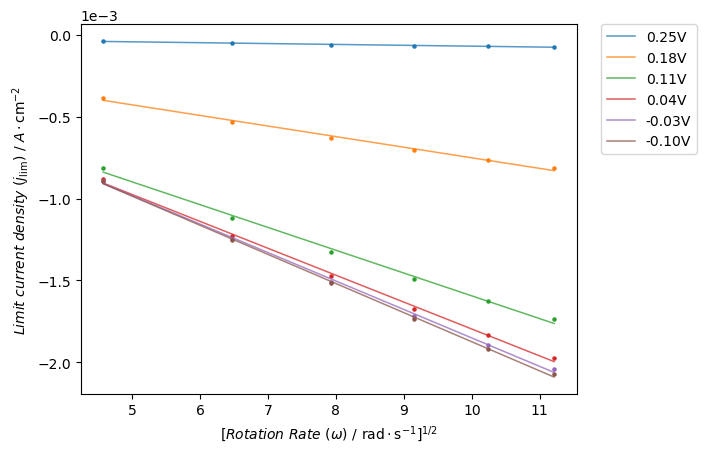

L_Fe_j saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
Summary Table of Calculated Parameters:
      Potential  Levich slope  Diffusion Coefficient
1638   0.249939     -0.000005          -3.305976e-08
2096   0.180054     -0.000065          -1.406748e-06
2555   0.110016     -0.000139          -4.441237e-06
3013   0.040131     -0.000164          -5.694497e-06
3472  -0.029907     -0.000174          -6.195169e-06
3931  -0.099945     -0.000178          -6.412293e-06


In [45]:
# show example Levich plot module V1 (current density) : updated in August 18th 2025 

# Define constants and parameters_These are setting parameter
start_value = -0.1  # Starting value of the range for potential
end_value = 0.25  # Ending value of the range for potential
n_points = 6  # Number of points to select
rpm_range = range(200, 2200, 100)  # RPM range for the files
# These are calculation parameter
n = 1
relectrode = 0.15 # Radius of the rotate electrode in cm
print('electrode Radius is :',relectrode,'cm')
A = np.pi*(relectrode**2)
print('surface area is :',A,'cm\u00b2')
v = 0.01 # kinematic viscosity of the solution (ν - cm2/s), 
C = 0.004e-3 #in mol/cm3

# Load data
Levich_plotshow_data = pd.DataFrame()
file = filepath + file_name
data0 = pd.ExcelFile(file)
df = data0.parse('Sheet1')
E = df['Potential applied (V)']

# Calculate the corresponding indices within the range
if E.iloc[0] < E.iloc[-1]:  # Ascending order
    start_index = E[E >= start_value].idxmin()
    end_index = E[E <= end_value].idxmax()
    print("E in Ascending order")
else:  # Descending order
    start_index = E[E <= end_value].idxmax()
    end_index = E[E >= start_value].idxmin()
    print("E in Descending order")

print("start_index:", start_index, "end_index:", end_index)

points_number = np.linspace(start_index, end_index, n_points, dtype=int)
E_selected = E.iloc[points_number]
Levich_slope = []
Levich_intercept = []
D = []

for j, potential in enumerate(E_selected):
    print(f"potential {j+1} : {potential:.4f} V")
    j_elected = []
    w_05 = []
 
    for i in rpm_range:
        #input your file name here and switch rpm in to %d
        file = filepath + file_names % i 
        if os.path.exists(file) and file.endswith(".xlsx"):
            data0 = pd.ExcelFile(file)
            df = data0.parse('Sheet1')
            # x axis（w）
            rpm = i
            w_i = rpm_to_rads(rpm)
            w05_i = w_i ** 0.5
            w_05.append(w05_i)

            # y axis (Ii)
            E = df['Potential applied (V)']
            I = df['WE(1).Current (A)']
            den_j = I/A
            # Apply the Gaussian filter to the 'Current (A)'
            smoothed_I = gaussian_filter(I, sigma=sigma)
            smoothed_j = gaussian_filter(den_j, sigma=sigma)
            
            j_potential_i = find_y(E,smoothed_j,potential)
            #print(I_potential_i)
            j_elected.append(j_potential_i)
        
    plt.scatter(w_05, j_elected, s=5)
    
    # Create a new DataFrame for the current RPM
    
    potential_data = pd.DataFrame({'w_05' + " {:.2f}".format(potential): w_05, 'j' + " {:.2f}".format(potential): j_elected})
        
    # Concatenate the data for this RPM to the right of the combined_data DataFrame
    Levich_plotshow_data = pd.concat([Levich_plotshow_data, potential_data], axis=1)

    # Perform linear regression
    coeffs = np.polyfit(w_05, j_elected, 1)
    
    # Store the regression information
    Levich_slope_j = coeffs[0]
    Levich_intercept_j = coeffs[1]
    Levich_slope.append(Levich_slope_j)
    Levich_intercept.append(Levich_intercept_j)
    
    x_regression = np.linspace(min(w_05), max(w_05), 100)
    y_regression = np.polyval(coeffs, x_regression)
    
    B = Levich_slope_j
    F = 96485.3321
    D23 = B/(0.62*n*F*(v**-(1/6))*C)
    if D23 >= 0:
        D_i = D23**(3/2)
    elif D23 < 0:
        D_i = -(-D23)**(3/2)
    else:
        print("No B value found")
    D.append(D_i)

    # Plot the regression line with transparency and thinner line
    plt.plot(x_regression, y_regression, label=f'{potential:.2f}V', alpha=0.75, linewidth=1.1)


#     # Calculate coordinates for the regression equation annotation
#     x_eq = max(w_05) - 0.1 * (max(w_05) - min(w_05))
#     y_eq = coeffs[0] * x_eq + coeffs[1]
    
#     # Add the regression equation close to the regression line
#     equation = f'y = {coeffs[0]:.2e}x + {coeffs[1]:.2e}'
#     plt.annotate(equation, xy=(x_eq, y_eq), xytext=(x_eq, y_eq), textcoords="offset points", xycoords="data", ha="center")


plt.xlabel(r'$[Rotation\ Rate\ (\omega)\ /\ \mathrm{rad\cdot s}^{-1}]^{1/2}$')
plt.ylabel(r'$Limit\ current\ density\ (j_{\mathrm{lim}})\ /\ A\cdot$cm$^{-2}$')

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
# plt.grid()

# Save as high-resolution PNG and Vector PDF
output_name = 'L_Fe_j' # Rename it
output_path = result_path
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, output_name + '.png')  # For raster format
plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
# plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
plt.show()
print(f"{output_name} saved in {result_path}")

# Create DataFrame
table_content = {
    'Potential': E_selected,
    'Levich slope': Levich_slope,
    'Diffusion Coefficient': D
}
table = pd.DataFrame(table_content)

# Show DataFrame
print("Summary Table of Calculated Parameters:")
print(table)
        

# # Save the data to a new Excel file
# Levich_plotshow_data.to_excel(filepath + '\\Levich_plotshow_data.xlsx', index=False)

now processing index: 0 E: -0.119781494140625
now processing index: 6 E: -0.117034912109375
now processing index: 12 E: -0.114288330078125
now processing index: 18 E: -0.111541748046875
now processing index: 24 E: -0.108795166015625
now processing index: 30 E: -0.106048583984375
now processing index: 36 E: -0.103302001953125
now processing index: 42 E: -0.100555419921875
now processing index: 48 E: -0.097808837890625
now processing index: 54 E: -0.095062255859375
now processing index: 60 E: -0.092315673828125
now processing index: 66 E: -0.089569091796875
now processing index: 72 E: -0.086822509765625
now processing index: 78 E: -0.084075927734375
now processing index: 84 E: -0.081329345703125
now processing index: 90 E: -0.078582763671875
now processing index: 96 E: -0.075836181640625
now processing index: 102 E: -0.073089599609375
now processing index: 108 E: -0.070343017578125
now processing index: 114 E: -0.067596435546875
now processing index: 120 E: -0.064849853515625
now process

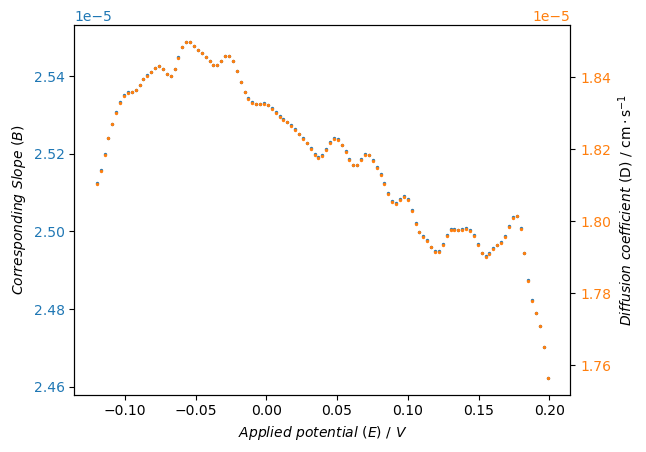

LA_Fe saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI


In [9]:
## Levich Analysis Moudle V2: updated in May 24th 2024

# Rest Calculation parameter from last moudle
# Define constants and parameters_These are setting parameter


E_selected = E.iloc[start_index:end_index+1]
# interval = 100  # potential going to select every ?
interval = math.floor(len(E_selected)/100)

Levich_slope = []
Levich_intercept = []
D = []
E_plot =[]

for j in range(0, len(E_selected), interval):
    potential = E_selected.iloc[j]
    
    print('now processing' , "index:",j , "E:", potential)
    w_05 = []
    Il = []
          
    for i in rpm_range:
        #input your file name here and switch rpm in to %d
        file = filepath + file_names % i 
        if os.path.exists(file) and file.endswith(".xlsx"):
          
            data0 = pd.ExcelFile(file)
            df = data0.parse('Sheet1')
            # x axis（w）
            rpm = i
            w_i = rpm_to_rads(rpm)
            w05_i = w_i ** 0.5
            w_05.append(w05_i)

            # y axis (Ii)
            E_irpm = df['Potential applied (V)']
            I_irpm = df['WE(1).Current (A)']
            
            # Apply the Gaussian filter to the 'Current (A)'
            I_irpm = gaussian_filter(I_irpm, sigma=sigma) 
            
            I_potential_i = find_y(E_irpm,I_irpm,potential)
            Il.append(I_potential_i)
#     print(w_05,Il)      
              
    # Perform linear regression
    coeffs = np.polyfit(w_05, Il, 1)
    Levich_slope_i = coeffs[0]
    intercept_i = coeffs[1]
    Levich_slope.append(Levich_slope_i)
    Levich_intercept.append(intercept_i)
    E_plot.append(potential)
    
# calculate D from B
# check these parameter
    B = Levich_slope_i
    F = 96485.3321
    D23 = B/(0.62*n*F*A*(v**-(1/6))*C)
    if D23 >= 0:
        D_i = D23**(3/2)
    elif D23 < 0:
        D_i = -(-D23)**(3/2)
    else:
        print("No B value found")
    D.append(D_i)

ig, ax1 = plt.subplots()

# Scatter plot for the first y-axis
ax1.scatter(E_plot, Levich_slope, s=2, color='#1f77b4')
ax1.set_xlabel('$Applied\ potential\ (E)\ /\ V$')
ax1.set_ylabel('$Corresponding\ Slope\ (B)$', color='k')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Create a second y-axis
ax2 = ax1.twinx()

# Scatter plot for the second y-axis
ax2.scatter(E_plot, D, s=2, color='#ff7f0e')
ax2.set_ylabel('$Diffusion\ coefficient\ (\mathrm{D})\ /\ \mathrm{cm\cdot s}^{-1}$', color='k')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# plt.grid()

# Save as high-resolution PNG and Vector PDF
output_name = 'LA_Fe' # Rename it
output_path = result_path
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, output_name + '.png')  # For raster format
plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
# plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
plt.show()
print(f"{output_name} saved in {result_path}")

# Levich_plot_data = pd.DataFrame({'E': E_plot, 'D': D, 'Slope': Levich_slope})
# # Save the data to a new Excel file
# Levich_plot_data.to_excel(filepath + '\\Levich_plot_data.xlsx', index=False)

Levich_D = D
Levich_E_selected = E_plot

In [9]:
math.floor(len(E_selected)/100)

37

E in Ascending order
start_index: 1922 end_index: 2620
potential 1 : -0.1198 V
potential 2 : -0.0562 V
potential 3 : 0.0079 V
potential 4 : 0.0716 V
potential 5 : 0.1357 V
potential 6 : 0.1997 V


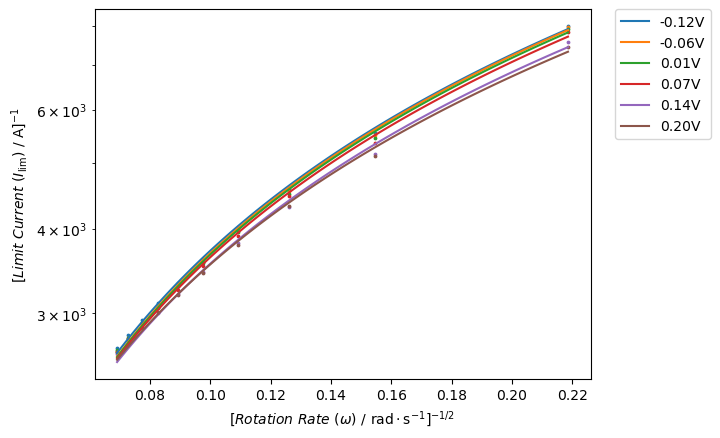

KL_Fe saved in C:\Users\Grant Xue\OneDrive\Desktop\J. Electroanalytical Chemistry 2023\images_300DPI
Summary Table of Calculated Parameters:
      Potential  Koutecky Levich slope  Diffusion Coefficient
1922  -0.119781           35388.358480               0.000022
2061  -0.056152           35408.402345               0.000022
2201   0.007935           35026.394072               0.000022
2340   0.071564           34372.717845               0.000023
2480   0.135651           32749.950231               0.000024
2620   0.199738           31849.566233               0.000025


In [14]:
# show example Koutecky-Levich plot module: updated in May 24th 2024


# Define constants and parameters_These are setting parameter
start_value = -0.12  # Starting value of the range for potential
end_value = 0.2  # Ending value of the range for potential
n_points = 6  # Number of points to select
rpm_range = range(200, 2200, 100)  # RPM range for the files

# Load data
Koutecky_Levich_plotshow_data = pd.DataFrame()
file = filepath + file_name
data0 = pd.ExcelFile(file)
df = data0.parse('Sheet1')
E = df['Potential applied (V)']

# Calculate the corresponding indices within the range
if E.iloc[0] < E.iloc[-1]:  # Ascending order
    start_index = E[E >= start_value].idxmin()
    end_index = E[E <= end_value].idxmax()
    print("E in Ascending order")
else:  # Descending order
    start_index = E[E <= end_value].idxmax()
    end_index = E[E >= start_value].idxmin()
    print("E in Descending order")

print("start_index:", start_index, "end_index:", end_index)

points_number = np.linspace(start_index, end_index, n_points, dtype=int)
E_selected = E.iloc[points_number]
Koutecky_Levich_slope = []
Koutecky_Levich_intercept = []
D = []

for j, potential in enumerate(E_selected):
    #find the corresponding I
    print(f"potential {j+1} : {potential:.4f} V")
    inverse_Im_elected = []
    w_n05 = []
 
    for i in rpm_range:
        #input your file name here and switch rpm in to %d
        file = filepath + file_names % i 
        if os.path.exists(file) and file.endswith(".xlsx"):
            data0 = pd.ExcelFile(file)
            df = data0.parse('Sheet1')
            # x axis（w）
            rpm = i
            w_i = rpm_to_rads(rpm)
            wn05_i = w_i ** -0.5
            w_n05.append(wn05_i)

            # y axis (Ii)
            E = df['Potential applied (V)']
            I = df['WE(1).Current (A)']
            # Apply the Gaussian filter to the 'Current (A)'
            smoothed_I = gaussian_filter(I, sigma=sigma)
            
            I_potential_i = find_y(E,smoothed_I,potential)
            
            inverse_Im_elected.append(1/I_potential_i)
#             print(1/I_potential_i)

    # Flag to determine whether to use a log plot
    log_plot = True  # Set to False if you don't want a log plot
    if log_plot:
        # Using absolute values for log plot to avoid issues with negative or zero values
        inverse_Im_elected = np.abs(inverse_Im_elected)
        plt.scatter(w_n05, inverse_Im_elected, s=3)
    else:
        plt.scatter(w_n05, inverse_Im_elected, s=3)
    
    # Create a new DataFrame for the current RPM
    
    potential_data = pd.DataFrame({'w_n05' + " {:.2f}".format(potential): w_n05, 'inverse_Im' + " {:.2f}".format(potential): inverse_Im_elected})
        
    # Concatenate the data for this E to the right of the DataFrame
    Koutecky_Levich_plotshow_data = pd.concat([Koutecky_Levich_plotshow_data, potential_data], axis=1)
    

    # Perform linear regression
    coeffs = np.polyfit(w_n05, inverse_Im_elected, 1)
    
    
    # Store the regression information
    Koutecky_Levich_slope_i = coeffs[0]
    Koutecky_Levich_intercept_i = coeffs[1]
    Koutecky_Levich_slope.append(Koutecky_Levich_slope_i)
    Koutecky_Levich_intercept.append(Koutecky_Levich_intercept_i)
    
    x_regression = np.linspace(min(w_n05), max(w_n05), 100)
    y_regression = np.polyval(coeffs, x_regression)
    
    # Calculate D from Koutecky_Levich_slope_i
    KL_slope = np.array(Koutecky_Levich_slope_i)**-1
    B = np.abs(KL_slope)
    F = 96485.3321
    D23 = B/(0.62*n*F*A*(v**-(1/6))*C)
    D_i = D23**(3/2)
    
    D.append(D_i)

    # Plot the regression line
    plt.plot(x_regression, y_regression, label=f'{potential:.2f}V')

#     # Calculate coordinates for the regression equation annotation
#     x_eq = max(w_n05) - 0.1 * (max(w_n05) - min(w_n05))
#     y_eq = coeffs[0] * x_eq + coeffs[1]
    
#     # Add the regression equation close to the regression line
#     equation = f'y = {coeffs[0]:.2e}x + {coeffs[1]:.2e}'
#     plt.annotate(equation, xy=(x_eq, y_eq), xytext=(-30, -30), textcoords="offset points", ha="center")

plt.xlabel(r'$[Rotation\ Rate\ (\omega)\ /\ \mathrm{rad\cdot s}^{-1}]^{-1/2}$')
plt.ylabel(r'$[Limit\ Current\ (I_{\mathrm{lim}})\ /\ \mathrm{A}]^{-1}$')

if log_plot:
    plt.yscale('log')  # Set y-axis to logarithmic scale
else:
    pass
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
# plt.grid()
output_name = 'KL_Fe' # Rename it
output_path = result_path
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, output_name + '.png')  # For raster format
plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
# plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
plt.show()
print(f"{output_name} saved in {result_path}")

# # Save the data to a new Excel file
# Koutecky_Levich_plotshow_data.to_excel(filepath + '\\Koutecky_Levich_plotshow_data.xlsx', index=False)

# Create DataFrame
table_content = {
    'Potential': E_selected,
    'Koutecky Levich slope': Koutecky_Levich_slope,
    'Diffusion Coefficient': D
}
table = pd.DataFrame(table_content)

# Show DataFrame
print("Summary Table of Calculated Parameters:")
print(table)
#_____________________________________________________

In [11]:
## Koutecky-Levich Analysis Moudle: updated in May 24th 2024
E_selected = E.iloc[start_index:end_index+1]
# interval = 100  # potential going to select every ?
interval = math.floor(len(E_selected)/100)

print('Number of Selected Potential:', len(E_selected))
Koutecky_Levich_slope = []
Koutecky_Levich_intercept = []
D = []
E_plot =[]

for j in range(0, len(E_selected), interval):
    potential = E_selected.iloc[j]
    
    print('now processing' , "index:",j , "E:", potential)
    inverse_wn05 = []
    inverse_Im = []
          
    for i in rpm_range:
        file = filepath + file_names % i
        if os.path.exists(file) and file.endswith(".xlsx"):
#             print(file)
            data0 = pd.ExcelFile(file)
            df = data0.parse('Sheet1')
            # x axis（w）
            rpm = i
            w_i = rpm_to_rads(rpm)
            inverse_wn05_i = w_i ** -0.5
            inverse_wn05.append(inverse_wn05_i)

            # y axis (Ii)
            E_irpm = df['Potential applied (V)']
            I_irpm = df['WE(1).Current (A)']
            
            # Apply the Gaussian filter to the 'Current (A)'
            I_irpm = gaussian_filter(I_irpm, sigma=sigma) 
            
            I_potential_i = find_y(E_irpm,I_irpm,potential)
            inverse_Im.append(1/I_potential_i)
#     print(wn05,Il)      
              
    # Perform linear regression
    coeffs = np.polyfit(inverse_wn05, inverse_Im, 1)
    Bi = coeffs[0]
    Intercept_i = coeffs[1]
    Koutecky_Levich_slope.append(Bi)
    Koutecky_Levich_intercept.append(Intercept_i**-1)
    E_plot.append(potential)
    
# calculate D from B
# check these parameter
KL_slope = np.array(Koutecky_Levich_slope)**-1
B = np.abs(KL_slope)
F = 96485.3321
D23 = B/(0.62*n*F*A*(v**-(1/6))*C)
D = D23**(3/2)

# calculate K0 from Intercept_i

k = np.array(Koutecky_Levich_intercept)/n*F*A*C


ig, ax1 = plt.subplots()

# Scatter plot for the first y-axis
ax1.scatter(E_plot, Koutecky_Levich_slope, s=2, color='#1f77b4')
ax1.set_xlabel('Applied potential/V')
ax1.set_ylabel('Corresponding Slope B', color='k')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Create a second y-axis
ax2 = ax1.twinx()

# Scatter plot for the second y-axis
ax2.scatter(E_plot, D, s=2, color='#ff7f0e')
ax2.set_yscale('log')  # Set y-axis to logarithmic scale
ax2.set_ylabel('Diffusion coefficient(D)/cm\u00b2/s', color='k')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

output_name = 'KLA_D' # Rename it
output_path = result_path
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, output_name + '.png')  # For raster format
plt.savefig(output_file, dpi=600, bbox_inches='tight')  # High-resolution raster
# plt.savefig("output_figure.pdf", format='pdf', bbox_inches='tight')  # Vector PDF
plt.show()
print(f"{output_name} saved in {result_path}")

# Koutecky_Levich_plot_data = pd.DataFrame({'E': E_plot, 'D': D, 'Slope': KL_slope})
# # Save the data to a new Excel file
# Koutecky_Levich_plot_data.to_excel(filepath + '\\Koutecky_Levich_plot_data.xlsx', index=False)

plt.scatter(E_plot, k, s=2, color='#1f77b4')
plt.xlabel('Applied potential/V')
plt.ylabel('Rate Constant k')
plt.show()



Koutecky_Levich_D = D
Koutecky_Levich_E_selected = E_plot

Number of Selected Potential: 699
now processing index: 0 E: -0.119781494140625
now processing index: 6 E: -0.117034912109375
now processing index: 12 E: -0.114288330078125
now processing index: 18 E: -0.111541748046875
now processing index: 24 E: -0.108795166015625
now processing index: 30 E: -0.106048583984375
now processing index: 36 E: -0.103302001953125
now processing index: 42 E: -0.100555419921875
now processing index: 48 E: -0.097808837890625
now processing index: 54 E: -0.095062255859375
now processing index: 60 E: -0.092315673828125
now processing index: 66 E: -0.089569091796875
now processing index: 72 E: -0.086822509765625
now processing index: 78 E: -0.084075927734375
now processing index: 84 E: -0.081329345703125
now processing index: 90 E: -0.078582763671875
now processing index: 96 E: -0.075836181640625
now processing index: 102 E: -0.073089599609375
now processing index: 108 E: -0.070343017578125
now processing index: 114 E: -0.067596435546875
now processing index: 120

KeyboardInterrupt: 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[(-0.3, -0.175), (0.45, 0.55)]


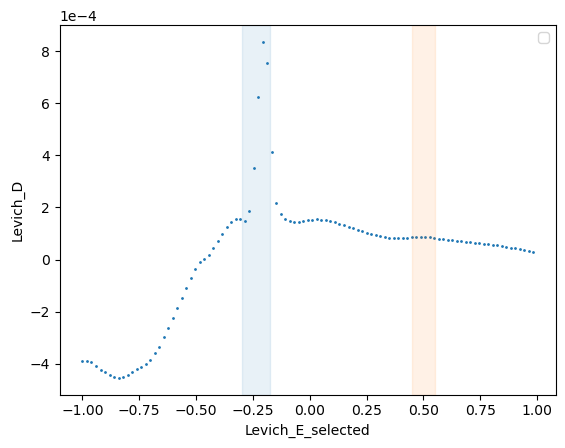

Range1 (-0.3, -0.175): Mean value of D = 0.0004839012329321796
Range2 (0.45, 0.55): Mean value of D = 8.596583612370672e-05
Mean values L: [0.0004839012329321796, 8.596583612370672e-05]


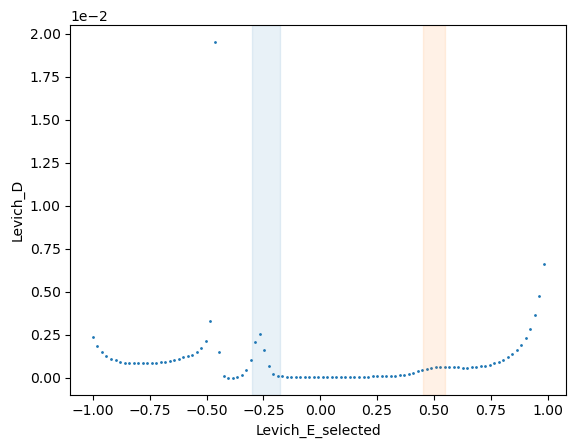

Range1 (-0.3, -0.175): Mean value of D = 0.0011987964953431333
Range2 (0.45, 0.55): Mean value of D = 0.0006021574350926234
Mean values KL: [0.0011987964953431333, 0.0006021574350926234]


In [14]:
print(D_ranges)
Levich_E_selected = pd.Series(Levich_E_selected)
Koutecky_Levich_E_selected = pd.Series(Koutecky_Levich_E_selected)

plt.scatter(Levich_E_selected, Levich_D, s=1)

for i, d_range in enumerate(D_ranges):
    color_value = tableau_colors[i % len(tableau_colors)]  # Cycle through Tableau colors
    plt.axvspan(d_range[0], d_range[1], ymin=0, ymax=1, alpha=0.1, color=color_value)

plt.xlabel('Levich_E_selected')
plt.ylabel('Levich_D')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# plt.xlim(-0.4,1.0)
# plt.ylim(-0.1e-4,0.3e-4)
plt.legend()
# plt.grid()
plt.show()

# Initialize an empty list to store the mean values
mean_values = []

for i, d_range in enumerate(D_ranges):
    start_index = Levich_E_selected[Levich_E_selected >= d_range[0]].idxmin()
    end_index = Levich_E_selected[Levich_E_selected <= d_range[1]].idxmax()
    
    # Ensure indices are valid and end_index is not less than start_index
    if start_index <= end_index:
        D_calculate = Levich_D[start_index:end_index+1]
        Di = np.mean(D_calculate)
        mean_values.append(Di)
        print(f"Range{i+1} {d_range}: Mean value of D = {Di}")
    else:
        print(f"Invalid range {d_range}: start_index ({start_index}) > end_index ({end_index})")

print("Mean values L:", mean_values)
    

plt.scatter(Koutecky_Levich_E_selected, Koutecky_Levich_D, s=1)
for i, d_range in enumerate(D_ranges):
    color_value = tableau_colors[i % len(tableau_colors)]  # Cycle through Tableau colors
    plt.axvspan(d_range[0], d_range[1], ymin=0, ymax=1, alpha=0.1, color=color_value)

plt.xlabel('Levich_E_selected')
plt.ylabel('Levich_D')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# plt.xlim(-0.4,1.0)
# plt.ylim(-0.1e-4,0.3e-4)
# plt.grid()
plt.show()

# Initialize an empty list to store the mean values
mean_values = []

for i, d_range in enumerate(D_ranges):
    start_index = Koutecky_Levich_E_selected[Koutecky_Levich_E_selected >= d_range[0]].idxmin()
    end_index = Koutecky_Levich_E_selected[Koutecky_Levich_E_selected <= d_range[1]].idxmax()
    
    # Ensure indices are valid and end_index is not less than start_index
    if start_index <= end_index:
        D_calculate = Koutecky_Levich_D[start_index:end_index+1]
        Di = np.mean(D_calculate)
        mean_values.append(Di)
        print(f"Range{i+1} {d_range}: Mean value of D = {Di}")
    else:
        print(f"Invalid range {d_range}: start_index ({start_index}) > end_index ({end_index})")

print("Mean values KL:", mean_values)

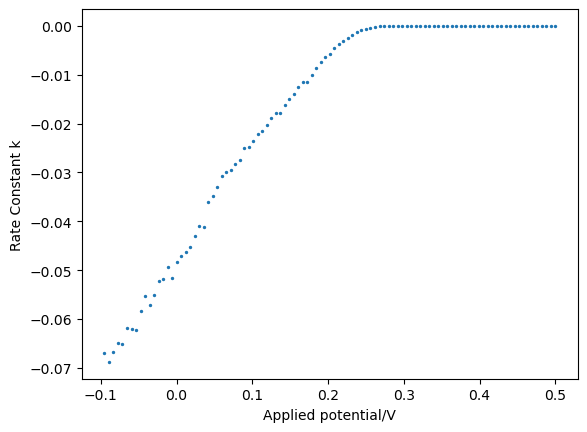

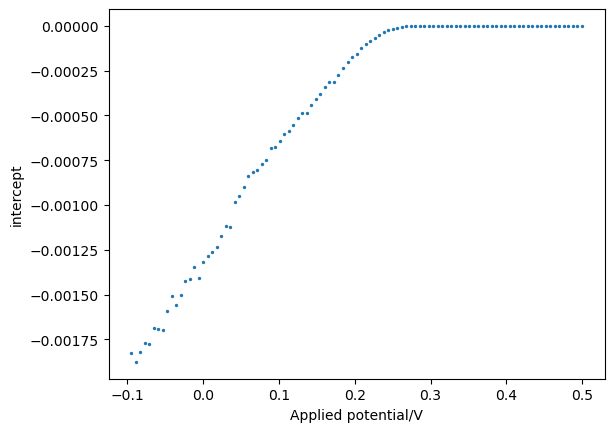

In [12]:
k = np.array(Koutecky_Levich_intercept)/(n*F*A*C)
plt.figure()
plt.scatter(E_plot, k, s=2, color='#1f77b4')
plt.xlabel('Applied potential/V')
plt.ylabel('Rate Constant k')
# plt.ylim([-0.005, 0.005])
plt.show()

plt.figure()
plt.scatter(E_plot, Koutecky_Levich_intercept, s=2, color='#1f77b4')
plt.xlabel('Applied potential/V')
plt.ylabel('intercept')
# plt.ylim([-1000, 1000])
plt.show()

In [30]:
n*F*C*A

0.027280584945407832